In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn


# Breast Cancer Prediction Model

The objective of this project is to create a breast cancer prediction model in order to categorize observations from a breast cancer image into benign or malignant, comparing the use of a decision tree model vs. a logistic regression model in python.

Using an accurate breast cancer prediction model can help support and guide doctors in providing better, quicker care to their patients during critical times or when patient volume is high. While these models do not aim to replace doctors, they can give doctors a second data-backed opinion to confirm their understanding of a breast cancer image.

**Dataset:** Wisconsin Breast Cancer Dataset (sklearn)  
**Models:** Decision Tree, Logistic Regression  


Correlations with diagnosis (sorted):
worst concave points      -0.793566
worst perimeter           -0.782914
mean concave points       -0.776614
worst radius              -0.776454
mean perimeter            -0.742636
worst area                -0.733825
mean radius               -0.730029
mean area                 -0.708984
mean concavity            -0.696360
worst concavity           -0.659610
mean compactness          -0.596534
worst compactness         -0.590998
radius error              -0.567134
perimeter error           -0.556141
area error                -0.548236
worst texture             -0.456903
worst smoothness          -0.421465
worst symmetry            -0.416294
mean texture              -0.415185
concave points error      -0.408042
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error           

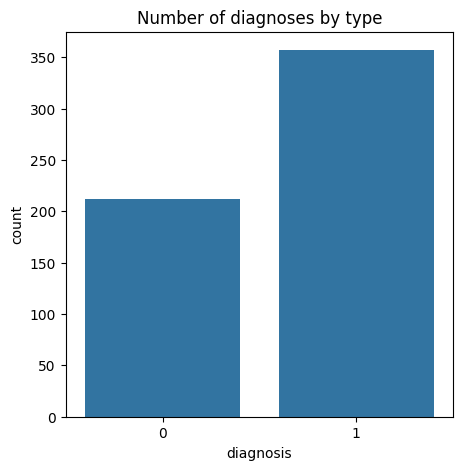

Predicted values:  [1 0 0 1 1 0 0 0 0 0 1 0 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0
 1 0 1]
Actual values:  204    1
70     0
131    0
431    1
540    1
567    0
369    0
29     0
81     1
477    1
457    1
167    0
165    1
329    0
527    1
83     0
511    1
556    1
101    1
535    0
73     0
394    1
393    0
425    1
305    1
76     1
384    1
555    1
362    1
72     0
551    1
158    1
424    1
532    1
222    1
55     1
10     0
281    1
6      0
90     1
Name: diagnosis, dtype: int64
0.9210526315789473


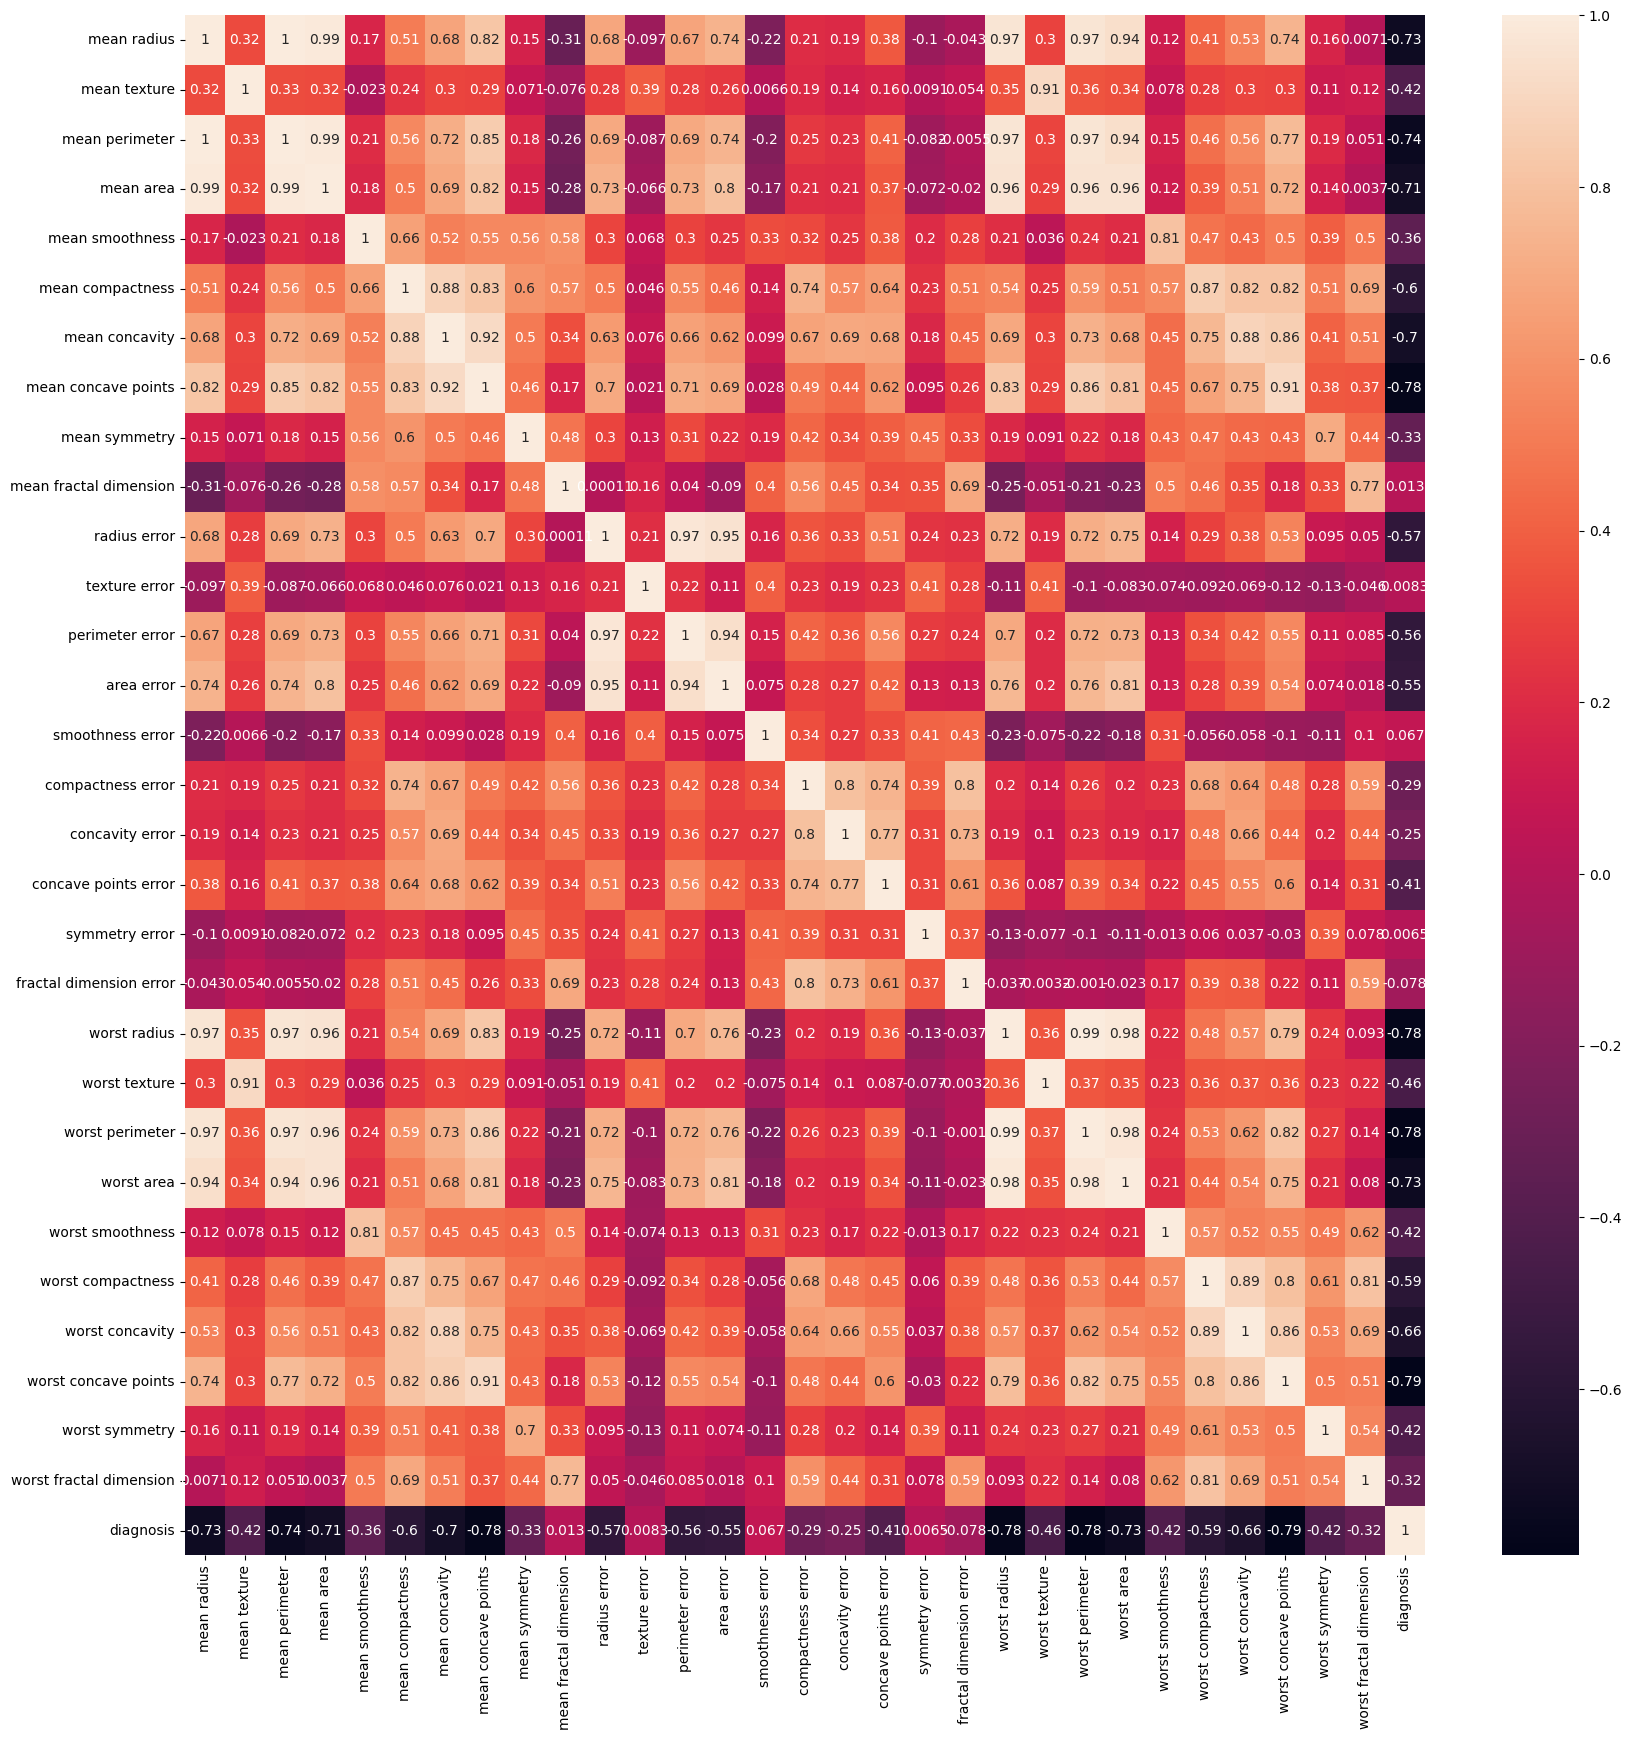

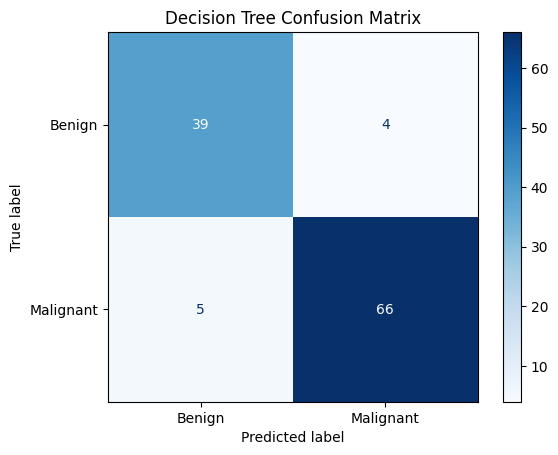

Predicted values:  [1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1]
Actual values:  204    1
70     0
131    0
431    1
540    1
567    0
369    0
29     0
81     1
477    1
457    1
167    0
165    1
329    0
527    1
83     0
511    1
556    1
101    1
535    0
73     0
394    1
393    0
425    1
305    1
76     1
384    1
555    1
362    1
72     0
551    1
158    1
424    1
532    1
222    1
55     1
10     0
281    1
6      0
90     1
Name: diagnosis, dtype: int64
0.956140350877193


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


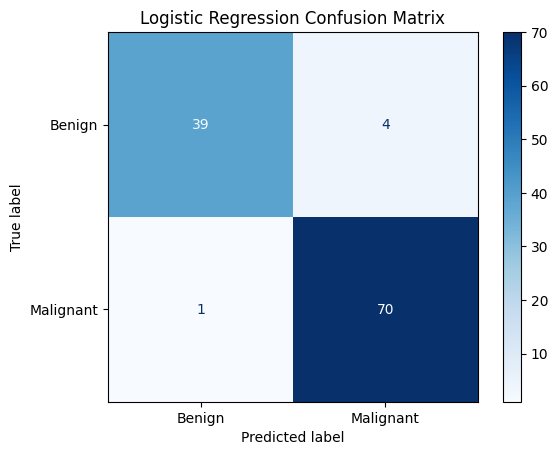

In [7]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target
df.head()

df.isnull().sum()
df.dtypes
df.describe()
correlation = df.corr()['diagnosis'].sort_values()
print("\nCorrelations with diagnosis (sorted):")
print(correlation)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,5))
sns.barplot(x=df['diagnosis'].value_counts().index,
           y=df['diagnosis'].value_counts().values)
plt.xlabel('diagnosis')
plt.ylabel('count')
plt.title('Number of diagnoses by type')
plt.show()

plt.figure(figsize=(20,20))
sns.heatmap(df.corr(),annot=True)

from sklearn.model_selection import train_test_split

X = df.drop(['diagnosis'], axis=1)
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

y_pred = dtree.predict(X_test)
print('Predicted values: ', y_pred[:40])
print('Actual values: ', y_test[:40])

print(dtree.score(X_test, y_test))

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
      display_labels=['Benign', 'Malignant'], cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.show()

from sklearn.linear_model import LogisticRegression

logModel = LogisticRegression()
logModel.fit(X_train, y_train)

yhat = logModel.predict(X_test)
print('Predicted values: ', yhat[:40])
print('Actual values: ', y_test[:40])

print(logModel.score(X_test, y_test))

ConfusionMatrixDisplay.from_predictions(y_test, yhat,
      display_labels=['Benign', 'Malignant'], cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()



## Conclusion

Both models performed well in predicting breast cancer diagnosis from
cell nucleus measurements. Logistic Regression outperformed the Decision
Tree, achieving an accuracy of 95.6% compared to 93.9% for the Decision
Tree.

Logistic Regression is the preferred model for achieving higher accuracy and being easier to interpret, when observing coefficients of individual variables.

Any real clinical application would require
significant rigorous validation before being used to support
medical decisions.